# King County House Price Prediction Project

**Dataset:** House Sales in King County, USA

**Objective:** Apply Big Data concepts to analyze housing data, visualize market trends, and build an advanced Machine Learning model to predict house prices using PySpark.

## 1. Spark Initialization and Data Loading

In [1]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg
import warnings
warnings.filterwarnings('ignore')

# Initialize Spark Session
spark = SparkSession.builder.appName("BigData_Project_KCHouse").getOrCreate()

# Load the dataset
df = spark.read.csv("kc_house_data.csv", header=True, inferSchema=True)

# Show schema and first 5 rows
df.printSchema()
df.show(5)

root
 |-- id: long (nullable = true)
 |-- date: string (nullable = true)
 |-- price: double (nullable = true)
 |-- bedrooms: integer (nullable = true)
 |-- bathrooms: double (nullable = true)
 |-- sqft_living: integer (nullable = true)
 |-- sqft_lot: integer (nullable = true)
 |-- floors: double (nullable = true)
 |-- waterfront: integer (nullable = true)
 |-- view: integer (nullable = true)
 |-- condition: integer (nullable = true)
 |-- grade: integer (nullable = true)
 |-- sqft_above: integer (nullable = true)
 |-- sqft_basement: integer (nullable = true)
 |-- yr_built: integer (nullable = true)
 |-- yr_renovated: integer (nullable = true)
 |-- zipcode: integer (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- sqft_living15: integer (nullable = true)
 |-- sqft_lot15: integer (nullable = true)

+----------+---------------+--------+--------+---------+-----------+--------+------+----------+----+---------+-----+----------+-------------+--------

## 2. Data Analysis & Insights
Applying PySpark DataFrame operations to extract meaningful insights from our data.

In [2]:
print("--- Data Insights ---")

# Insight 1: Filtering (Find large houses with more than 4 bedrooms)
large_houses = df.filter(col('bedrooms') > 4).count()
print(f"Number of houses with more than 4 bedrooms: {large_houses}")

# Insight 2: Grouping & Aggregation (Calculate average price based on house condition)
print("\nAverage Price by Property Condition (1-5):")
df.groupBy("condition").agg(avg("price").alias("Avg_Price")).orderBy("condition").show()

# Insight 3: Average price per Zipcode (Showing top 5 most expensive areas)
print("Top 5 Most Expensive Zipcodes on Average:")
df.groupBy("zipcode").agg(avg("price").alias("Avg_Price")).orderBy(col("Avg_Price").desc()).show(5)

--- Data Insights ---
Number of houses with more than 4 bedrooms: 1935

Average Price by Property Condition (1-5):
+---------+-----------------+
|condition|        Avg_Price|
+---------+-----------------+
|        1|334431.6666666667|
|        2|327287.1453488372|
|        3|542012.5781483857|
|        4|521200.3900334566|
|        5|612418.0893592004|
+---------+-----------------+

Top 5 Most Expensive Zipcodes on Average:
+-------+------------------+
|zipcode|         Avg_Price|
+-------+------------------+
|  98039|         2160606.6|
|  98004|1355927.0820189274|
|  98040|1194230.0212765958|
|  98112| 1095499.342007435|
|  98102| 901258.2666666667|
+-------+------------------+
only showing top 5 rows


## 3. Data Visualization (Market Insights)
Converting aggregated PySpark DataFrames into Pandas to leverage Matplotlib and Seaborn for visual insights.

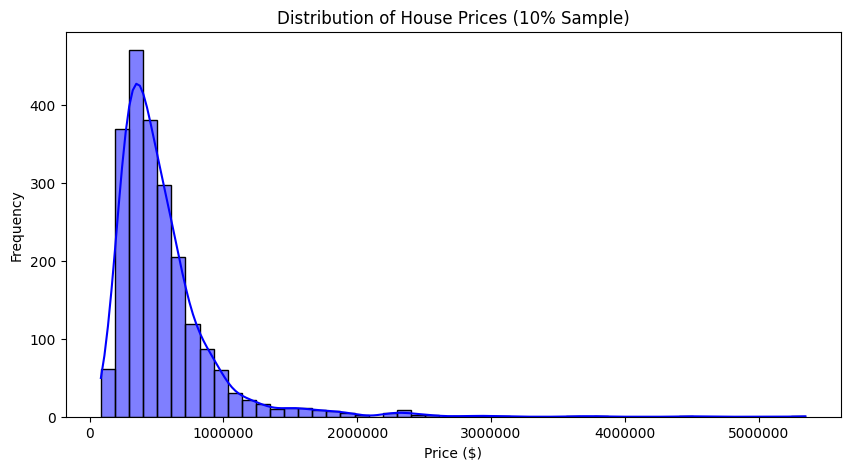

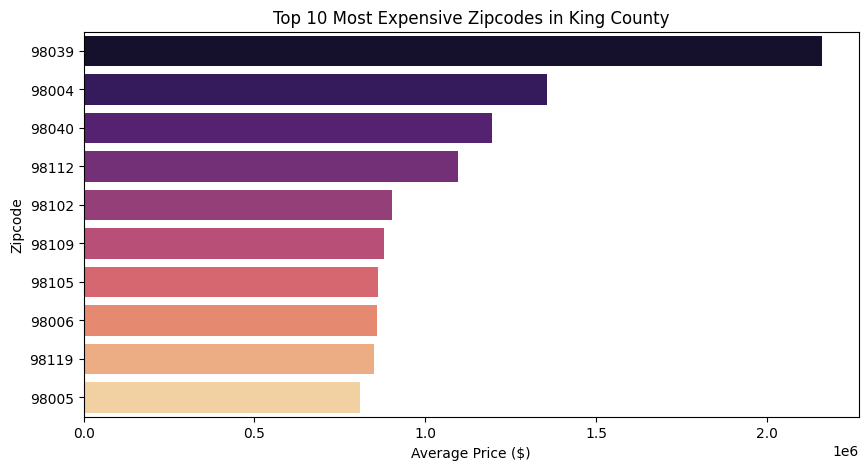

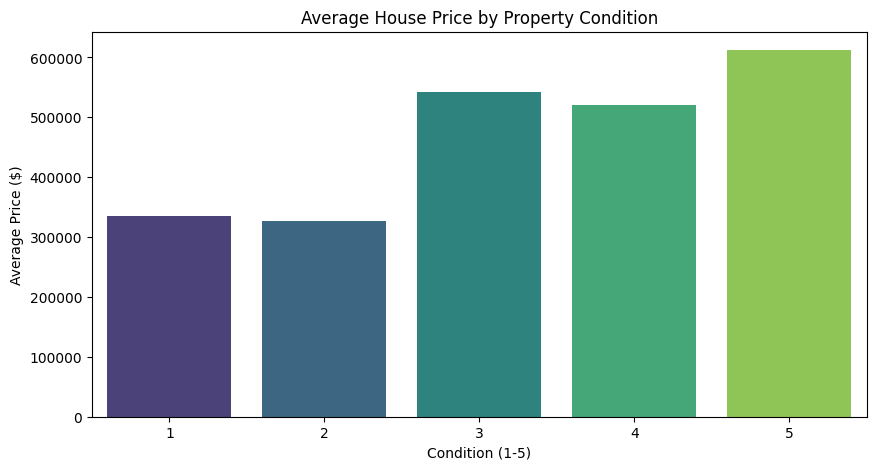

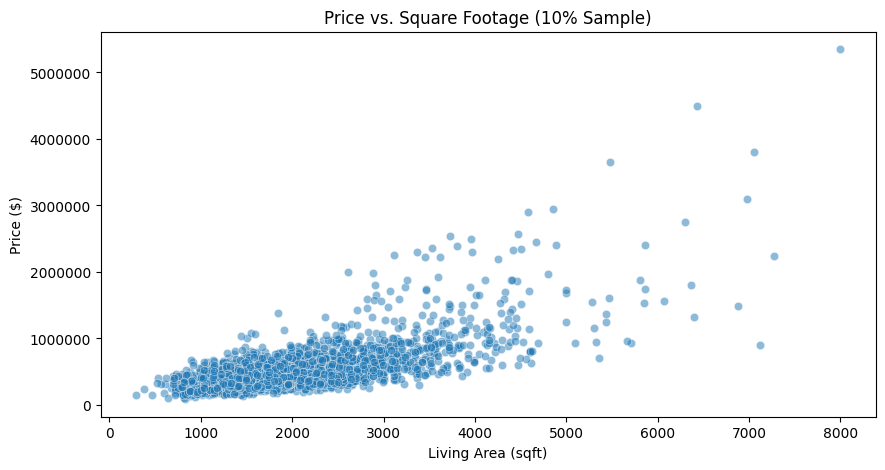

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Price Distribution ---
price_pd = df.select("price").sample(False, 0.1, seed=42).toPandas()
plt.figure(figsize=(10, 5))
sns.histplot(price_pd['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of House Prices (10% Sample)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# --- 2. Top 10 Most Expensive Zipcodes ---
zip_pd = df.groupBy("zipcode").agg(avg("price").alias("Avg_Price")).orderBy(col("Avg_Price").desc()).limit(10).toPandas()
plt.figure(figsize=(10, 5))
sns.barplot(x='Avg_Price', y=zip_pd['zipcode'].astype(str), data=zip_pd, palette='magma')
plt.title('Top 10 Most Expensive Zipcodes in King County')
plt.xlabel('Average Price ($)')
plt.ylabel('Zipcode')
plt.show()

# --- 3. Average Price by Condition ---
cond_pd = df.groupBy("condition").agg(avg("price").alias("Avg_Price")).orderBy("condition").toPandas()
plt.figure(figsize=(10, 5))
sns.barplot(x='condition', y='Avg_Price', data=cond_pd, palette='viridis')
plt.title('Average House Price by Property Condition')
plt.xlabel('Condition (1-5)')
plt.ylabel('Average Price ($)')
plt.show()

# --- 4. Price vs. Square Footage ---
sample_pd = df.select("sqft_living", "price").sample(False, 0.1, seed=42).toPandas()
plt.figure(figsize=(10, 5))
sns.scatterplot(x='sqft_living', y='price', data=sample_pd, alpha=0.5)
plt.title('Price vs. Square Footage (10% Sample)')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## 4. Machine Learning: Data Preprocessing & Pipeline

**Algorithm Chosen:** Gradient-Boosted Trees (GBTRegressor)

**Why this algorithm?** Real estate pricing is highly complex and rarely follows a perfect straight line. Standard Linear Regression struggles with non-linear data. Gradient-Boosted Trees are an ensemble learning method that builds multiple decision trees sequentially, with each tree correcting the errors of the previous ones. This makes it highly robust to outliers and significantly more accurate for housing data.

**Feature Engineering:** We calculate a new feature, `house_age`, to give the model better historical context. We also use `StringIndexer` and `OneHotEncoder` to properly handle categorical geographic data (`zipcode`).

In [4]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml import Pipeline

# Feature Engineering: Create 'house_age' and cast zipcode to string
df_ml = df.withColumn("zipcode_str", col("zipcode").cast("string")) \
          .withColumn("house_age", 2015 - col("yr_built"))

# Define Features
categoricalColumns = ['zipcode_str']  
numericColumns = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
                  'waterfront', 'view', 'condition', 'grade', 'house_age']

stages = []

# 1. Handle Categorical Columns
for categoricalCol in categoricalColumns:
    indexer = StringIndexer(inputCol=categoricalCol, outputCol=categoricalCol + "Index", handleInvalid="keep")
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[categoricalCol + "classVec"])
    stages += [indexer, encoder]

# 2. Vectorize Features
assemblerInputs = [c + "classVec" for c in categoricalColumns] + numericColumns
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]

# 3. Model Definition: Gradient-Boosted Trees
gbt = GBTRegressor(featuresCol="features", labelCol="price", predictionCol="prediction", maxIter=50)
stages += [gbt]

# 4. Build Pipeline & Split Data
pipeline = Pipeline(stages=stages)
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)

# 5. Train Model
print("Training the Gradient-Boosted Trees model... (This might take a minute)")
pipelineModel = pipeline.fit(train_data)
print("Pipeline constructed and GBT model successfully trained!")

Training the Gradient-Boosted Trees model... (This might take a minute)
Pipeline constructed and GBT model successfully trained!


## 5. Model Evaluation & Results Visualization
Evaluating the model using RMSE and R-Squared on the test set, and visualizing its predictive accuracy.

Root Mean Squared Error (RMSE): $164,615.04
R-Squared (R2) Model Accuracy: 0.8016



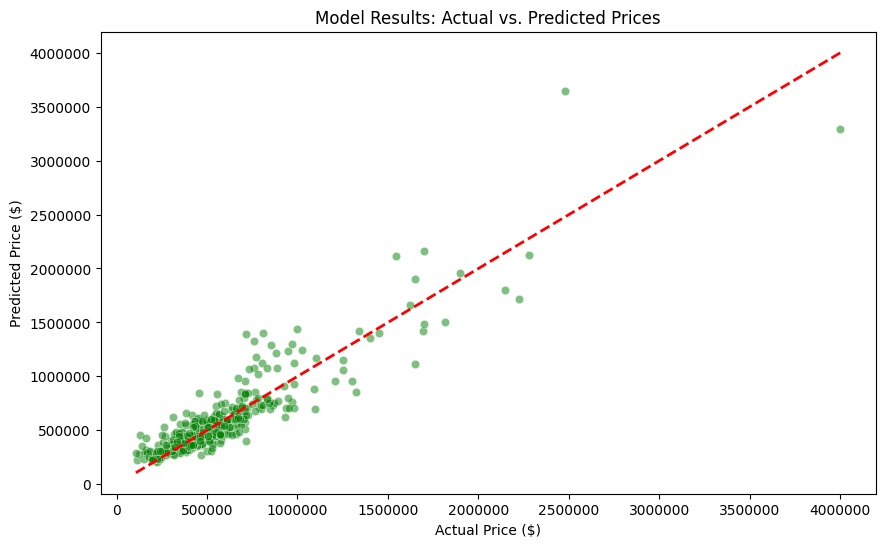

In [5]:
from pyspark.ml.evaluation import RegressionEvaluator

# Generate Predictions
predictions = pipelineModel.transform(test_data)

# Evaluate metrics
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")
rmse = evaluator_rmse.evaluate(predictions)
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")
r2 = evaluator_r2.evaluate(predictions)
print(f"R-Squared (R2) Model Accuracy: {r2:.4f}\n")

# --- Visualizing the Results (Actual vs Predicted) ---
preds_pd = predictions.select("price", "prediction").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='prediction', data=preds_pd, alpha=0.5, color='green')

# Perfect prediction line
min_val = min(preds_pd['price'].min(), preds_pd['prediction'].min())
max_val = max(preds_pd['price'].max(), preds_pd['prediction'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.title('Model Results: Actual vs. Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.ticklabel_format(style='plain', axis='both')
plt.show()